In [1]:
import os


!mkdir -p ~/.kaggle
!mv /content/kaggle.json ~/.kaggle/

# Set permissions for the json file
!chmod 600 ~/.kaggle/kaggle.json




! kaggle datasets download msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
  0% 0.00/60.3M [00:00<?, ?B/s]
100% 60.3M/60.3M [00:00<00:00, 1.33GB/s]


In [2]:
! unzip fer2013.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/sad/Training_65242339.jpg  
  inflating: train/sad/Training_65267116.jpg  
  inflating: train/sad/Training_65275626.jpg  
  inflating: train/sad/Training_6529266.jpg  
  inflating: train/sad/Training_65329617.jpg  
  inflating: train/sad/Training_65338712.jpg  
  inflating: train/sad/Training_65338797.jpg  
  inflating: train/sad/Training_65387162.jpg  
  inflating: train/sad/Training_65404494.jpg  
  inflating: train/sad/Training_65426218.jpg  
  inflating: train/sad/Training_65430136.jpg  
  inflating: train/sad/Training_65437377.jpg  
  inflating: train/sad/Training_6545735.jpg  
  inflating: train/sad/Training_65463385.jpg  
  inflating: train/sad/Training_65473985.jpg  
  inflating: train/sad/Training_65502829.jpg  
  inflating: train/sad/Training_65505359.jpg  
  inflating: train/sad/Training_65508578.jpg  
  inflating: train/sad/Training_65516023.jpg  
  inflating: train/sad/Training_65524027.jpg  
  inflating

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# Scikit-learn imports
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.model_selection import train_test_split




# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
    Input, GlobalAveragePooling2D, SeparableConv2D, Multiply,Lambda
)
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0, ResNet50V2, VGG16, ResNet50, DenseNet121, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
import warnings
warnings.filterwarnings('ignore')

In [4]:
# img_shape = 48
# batch_size = 64
# TRAIN_PATH = '../input/fer2013/train/'
# TEST_PATH = '../input/fer2013/test/'

IMAGE_SIZE = 96
BATCH_SIZE = 32
EPOCHS = 100

TRAIN_PATH = "/content/train"
TEST_PATH = "/content/test"
SELECTED_CLASSES = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise','disgust']

In [5]:
train_preprocessor = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

test_preprocessor = ImageDataGenerator(rescale=1./255)

# Create training generator
train_generator = train_preprocessor.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    classes=SELECTED_CLASSES,
    shuffle=True
)

# Create validation generator
validation_generator = train_preprocessor.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    classes=SELECTED_CLASSES,
    shuffle=False
)

# Create test generator
test_generator = test_preprocessor.flow_from_directory(
    TEST_PATH,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    classes=SELECTED_CLASSES
)

print("\n✅ Data generators created successfully!")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.

✅ Data generators created successfully!
Training samples: 22968
Validation samples: 5741
Test samples: 7178


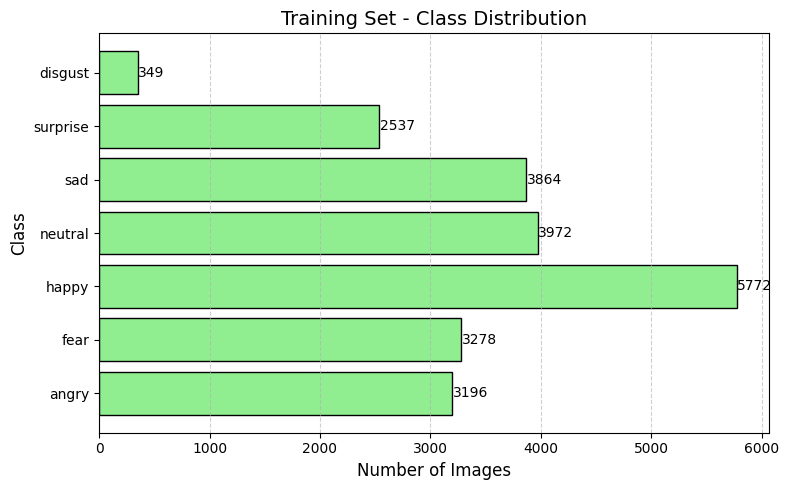

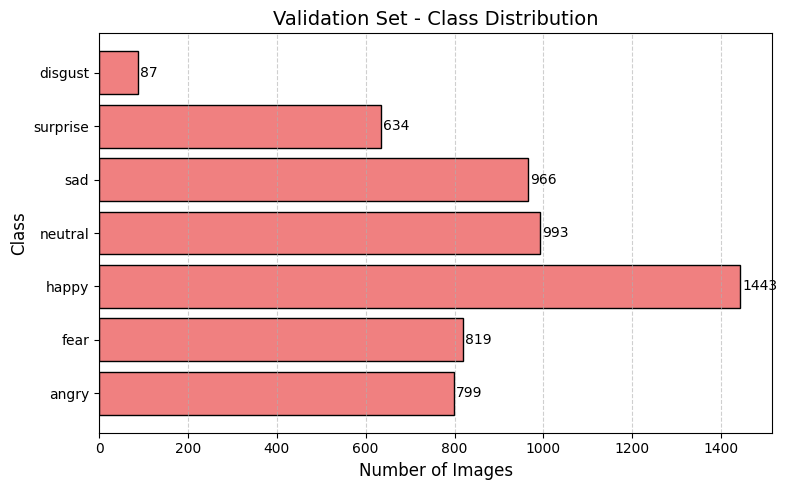

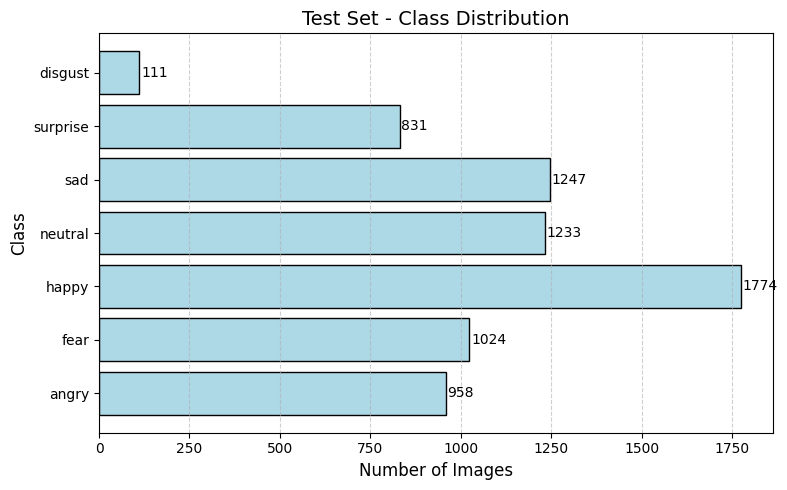

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def visualize_class_distribution(data_gen, dataset_name="Dataset", color='skyblue'):

    # Extract class indices and labels
    class_indices = data_gen.class_indices
    class_labels = list(class_indices.keys())
    class_counts = pd.Series(data_gen.classes).value_counts().sort_index()

    # Match labels to their counts
    class_counts.index = [class_labels[i] for i in class_counts.index]

    # Plot
    plt.figure(figsize=(8, 5))
    bars = plt.barh(class_counts.index, class_counts.values, color=color, edgecolor='black')
    plt.title(f"{dataset_name} - Class Distribution", fontsize=14)
    plt.xlabel("Number of Images", fontsize=12)
    plt.ylabel("Class", fontsize=12)

    # Annotate bar values
    for bar in bars:
        plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f"{int(bar.get_width())}", va='center', fontsize=10)

    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
visualize_class_distribution(train_generator, "Training Set", color='lightgreen')
visualize_class_distribution(validation_generator, "Validation Set", color='lightcoral')
visualize_class_distribution(test_generator, "Test Set", color='lightblue')

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, MaxPooling2D,
                                     Dropout, Flatten, Dense, Concatenate,
                                     GlobalAveragePooling2D)
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

def efficientnetb0_hybrid_model(input_shape=(96,96,1), num_classes=7, l2_reg=0.001,
                                efficientnet_weights='imagenet',
                                freeze_base=True,
                                unfreeze_last_n=20):
    # ----- Input -----
    inputs = Input(shape=input_shape)

    # If grayscale, expand to RGB properly (no Lambda!)
    if input_shape[-1] == 1:
        # Concatenate the same channel 3 times
        x3 = Concatenate(axis=-1)([inputs, inputs, inputs])
    else:
        x3 = inputs

    # ----- EfficientNetB0 branch -----
    base_model = EfficientNetB0(include_top=False,
                                weights=efficientnet_weights,
                                input_shape=(input_shape[0], input_shape[1], 3))

    # Freeze layers except last N if requested
    if freeze_base:
        for layer in base_model.layers[:-unfreeze_last_n]:
            layer.trainable = False
        for layer in base_model.layers[-unfreeze_last_n:]:
            layer.trainable = True
    else:
        base_model.trainable = True

    enet_out = base_model(x3)
    enet_out = GlobalAveragePooling2D()(enet_out)
    enet_out = Dense(256, activation='relu')(enet_out)

    # ----- Custom CNN branch -----
    c = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    c = Conv2D(64, (3,3), activation='relu', padding='same')(c)
    c = BatchNormalization()(c)
    c = MaxPooling2D((2,2))(c)
    c = Dropout(0.25)(c)

    c = Conv2D(128, (5,5), activation='relu', padding='same')(c)
    c = BatchNormalization()(c)
    c = MaxPooling2D((2,2))(c)
    c = Dropout(0.25)(c)

    c = Conv2D(256, (3,3), activation='relu', padding='same',
               kernel_regularizer=regularizers.l2(l2_reg))(c)
    c = BatchNormalization()(c)
    c = MaxPooling2D((2,2))(c)
    c = Dropout(0.25)(c)

    c = Conv2D(512, (3,3), activation='relu', padding='same',
               kernel_regularizer=regularizers.l2(l2_reg))(c)
    c = BatchNormalization()(c)
    c = MaxPooling2D((2,2))(c)
    c = Dropout(0.25)(c)

    c = Flatten()(c)
    c = Dense(256, activation='relu')(c)
    c = BatchNormalization()(c)
    c = Dropout(0.25)(c)

    # ----- Fusion -----
    merged = Concatenate()([enet_out, c])

    x = Dense(512, activation='relu')(merged)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name="HybridEfficientNet_CNN")
    return model

In [ ]:
print("Building hybrid EfficientNet + Custom CNN model...")
hybrid_model = efficientnetb0_hybrid_model((96,96,1), len(SELECTED_CLASSES),
                                                efficientnet_weights='imagenet',
                                                freeze_base=True,
                                                unfreeze_last_n=20,
                                                l2_reg=0.01)

hybrid_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
hybrid_model.summary()

Building hybrid EfficientNet + Custom CNN model...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "HybridEfficientNet_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 96,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 96, 96,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 96, 96,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 48, 48,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 48, 48,    │    204,928 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 24,    │          0 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 24, 24,    │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 12, 12,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 12, 12,    │          0 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 12, 12,    │  1,180,160 │ dropout_2[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 12,    │      2,048 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 6, 6, 512) │          0 │ batch_normalizat

 Total params: 11,199,146 (42.72 MB)

 Trainable params: 8,496,567 (32.41 MB)

 Non-trainable params: 2,702,579 (10.31 MB)

In [ ]:
# Store training histories and results for comparison at the end
histories = {}
results = {}


TRAINING HYBRID EFFICIENTNET + CUSTOM CNN MODEL
Epoch 1/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.1709 - loss: 7.6972
Epoch 1: val_accuracy improved from -inf to 0.21529, saving model to best_hybrid_efficientnet_custom_model.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 167s 160ms/step - accuracy: 0.1709 - loss: 7.6969 - val_accuracy: 0.2153 - val_loss: 7.0014 - learning_rate: 1.0000e-04
Epoch 2/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1879 - loss: 6.7218
Epoch 2: val_accuracy improved from 0.21529 to 0.22818, saving model to best_hybrid_efficientnet_custom_model.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 61s 84ms/step - accuracy: 0.1879 - loss: 6.7214 - val_accuracy: 0.2282 - val_loss: 5.7458 - learning_rate: 1.0000e-04
Epoch 3/100
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2093 - loss: 5.6750
Epoch 3: val_accuracy did not improve from 0.22818
718/718 ━━━━━━━━━━━━━━━━━━━━ 60s 84ms/step - accuracy: 0.2093 - loss: 5.6747 - val_accuracy: 0.2190 - val_loss

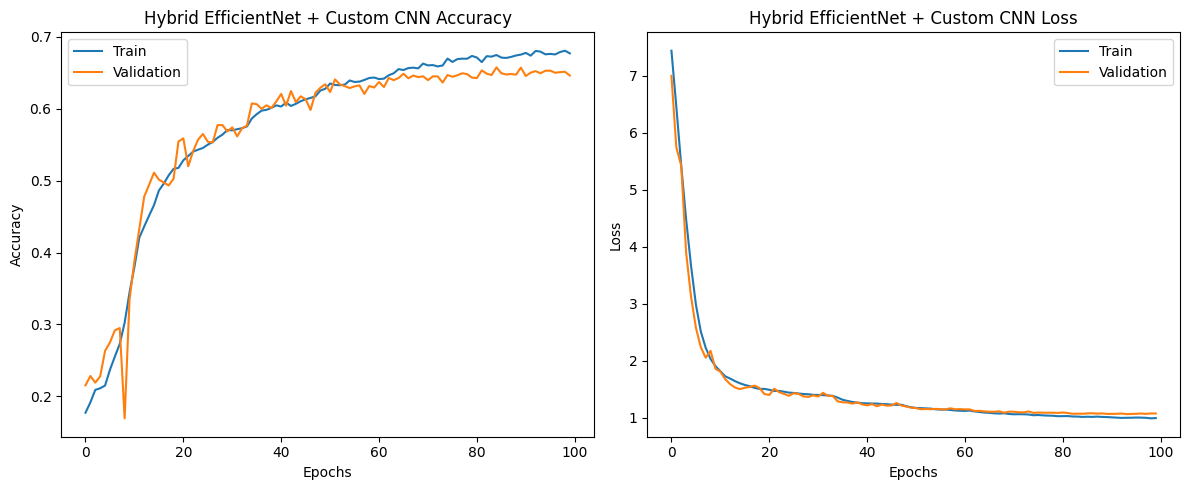

225/225 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step


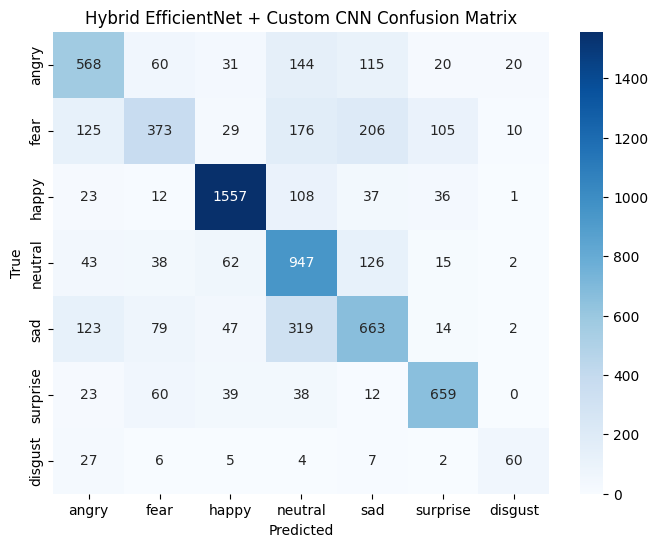


Classification Report (Hybrid EfficientNet + Custom CNN):

              precision    recall  f1-score   support

       angry       0.61      0.59      0.60       958
        fear       0.59      0.36      0.45      1024
       happy       0.88      0.88      0.88      1774
     neutral       0.55      0.77      0.64      1233
         sad       0.57      0.53      0.55      1247
    surprise       0.77      0.79      0.78       831
     disgust       0.63      0.54      0.58       111

    accuracy                           0.67      7178
   macro avg       0.66      0.64      0.64      7178
weighted avg       0.68      0.67      0.67      7178

✅ Hybrid EfficientNet + Custom CNN model saved!



In [ ]:
# ==============================================
# 1️⃣ Train and Evaluate Hybrid EfficientNet + Custom CNN Model
# ==============================================

print("\n" + "="*60)
print("TRAINING HYBRID EFFICIENTNET + CUSTOM CNN MODEL")
print("="*60)

# Callbacks (same as before)
checkpoint = ModelCheckpoint(
    "best_hybrid_efficientnet_custom_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode='max',
    verbose=1
)
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=15,
    restore_best_weights=True,
    mode='max',
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)
callbacks = [checkpoint, early_stop, reduce_lr]


# Train the model
history_hybrid = hybrid_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
histories['hybrid_efficientnet_custom'] = history_hybrid

# Evaluate on test data
test_loss, test_acc = hybrid_model.evaluate(test_generator, verbose=0)
results['hybrid_efficientnet_custom'] = {'accuracy': test_acc, 'loss': test_loss}
print(f"\nHybrid EfficientNet + Custom CNN - Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# Accuracy & Loss Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_hybrid.history['accuracy'], label='Train')
plt.plot(history_hybrid.history['val_accuracy'], label='Validation')
plt.title("Hybrid EfficientNet + Custom CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_hybrid.history['loss'], label='Train')
plt.plot(history_hybrid.history['val_loss'], label='Validation')
plt.title("Hybrid EfficientNet + Custom CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Confusion Matrix and Classification Report
pred_hybrid = hybrid_model.predict(test_generator)
y_pred_hybrid = np.argmax(pred_hybrid, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Hybrid EfficientNet + Custom CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\nClassification Report (Hybrid EfficientNet + Custom CNN):\n")
print(classification_report(y_true, y_pred_hybrid, target_names=class_labels))

# Save model
hybrid_model.save("fer_hybrid_efficientnet_custom_model.h5")
print("✅ Hybrid EfficientNet + Custom CNN model saved!\n")

In [ ]:
# ==============================================
# 🧩 1️⃣ Imports & Setup
# ==============================================
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image


In [ ]:
# ==============================================
# ⚙️ 2️⃣ Model & Cascade Initialization
# ==============================================

# Paths (make sure these are set correctly)
VAL_DIR = TEST_PATH  # path to test set
CLASS_LABELS = SELECTED_CLASSES  # emotion labels
IMAGE_SIZE = 96  # must match your model input size

# Load your trained hybrid model
print("Loading Hybrid Emotion Model...")
# hybrid_model should already be defined or loaded before this
hybrid_model = tf.keras.models.load_model('/content/best_hybrid_efficientnet_custom_model.keras')

# Load Haar Cascade for face detection
print("Loading Haar Cascade Classifier...")
HAAR_PATH = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(HAAR_PATH)


Loading Hybrid Emotion Model...


Loading Haar Cascade Classifier...


In [ ]:
# ==============================================
# 🧠 3️⃣ Helper Functions
# ==============================================

def detect_faces(image_path):
    """Detect faces in an image and return face regions with coordinates."""
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    face_regions = []
    for (x, y, w, h) in faces:
        face_regions.append((gray[y:y+h, x:x+w], (x, y, w, h)))

    return img, face_regions


def preprocess_face(face_img):
    """Resize, normalize, and expand dims for model prediction."""
    face_resized = cv2.resize(face_img, (IMAGE_SIZE, IMAGE_SIZE))
    face_resized = face_resized / 255.0
    face_resized = np.expand_dims(face_resized, axis=-1)  # grayscale channel
    face_resized = np.expand_dims(face_resized, axis=0)   # batch dimension
    return face_resized


def predict_emotion(face_img):
    """Predict emotion and return label + confidence."""
    preprocessed = preprocess_face(face_img)
    preds = hybrid_model.predict(preprocessed, verbose=0)
    pred_label = CLASS_LABELS[np.argmax(preds)]
    confidence = np.max(preds) * 100
    return pred_label, confidence


In [ ]:
# ==============================================
# 🧩 4️⃣ Main Evaluation Function
# ==============================================

def evaluate_hybrid_model(num_samples=10):
    """Test hybrid model on random test images with face detection."""

    all_classes = os.listdir(VAL_DIR)
    random_images = []

    # Pick random images
    for _ in range(num_samples):
        class_name = random.choice(all_classes)
        class_path = os.path.join(VAL_DIR, class_name)
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)
        random_images.append((img_path, class_name))

    plt.figure(figsize=(15, 10))

    for i, (img_path, true_label) in enumerate(random_images):
        img, faces = detect_faces(img_path)

        if len(faces) == 0:
            # No face detected
            plt.subplot(2, 5, i + 1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(f"True: {true_label}\nNo Face Detected", color='gray')
            plt.axis('off')
            continue

        # Predict only for the first face (or loop for multiple)
        (face_gray, (x, y, w, h)) = faces[0]
        pred_label, confidence = predict_emotion(face_gray)

        # Draw rectangle around face
        color = (0, 255, 0) if pred_label == true_label else (0, 0, 255)
        cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)

        # Add label text on image
        label_text = f"{pred_label} ({confidence:.1f}%)"
        cv2.putText(img, label_text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, color, 2)

        plt.subplot(2, 5, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"True: {true_label}", color='green' if pred_label == true_label else 'red')
        plt.axis('off')

    plt.suptitle("Hybrid EfficientNet + Custom CNN — Face Detection on Test Samples", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


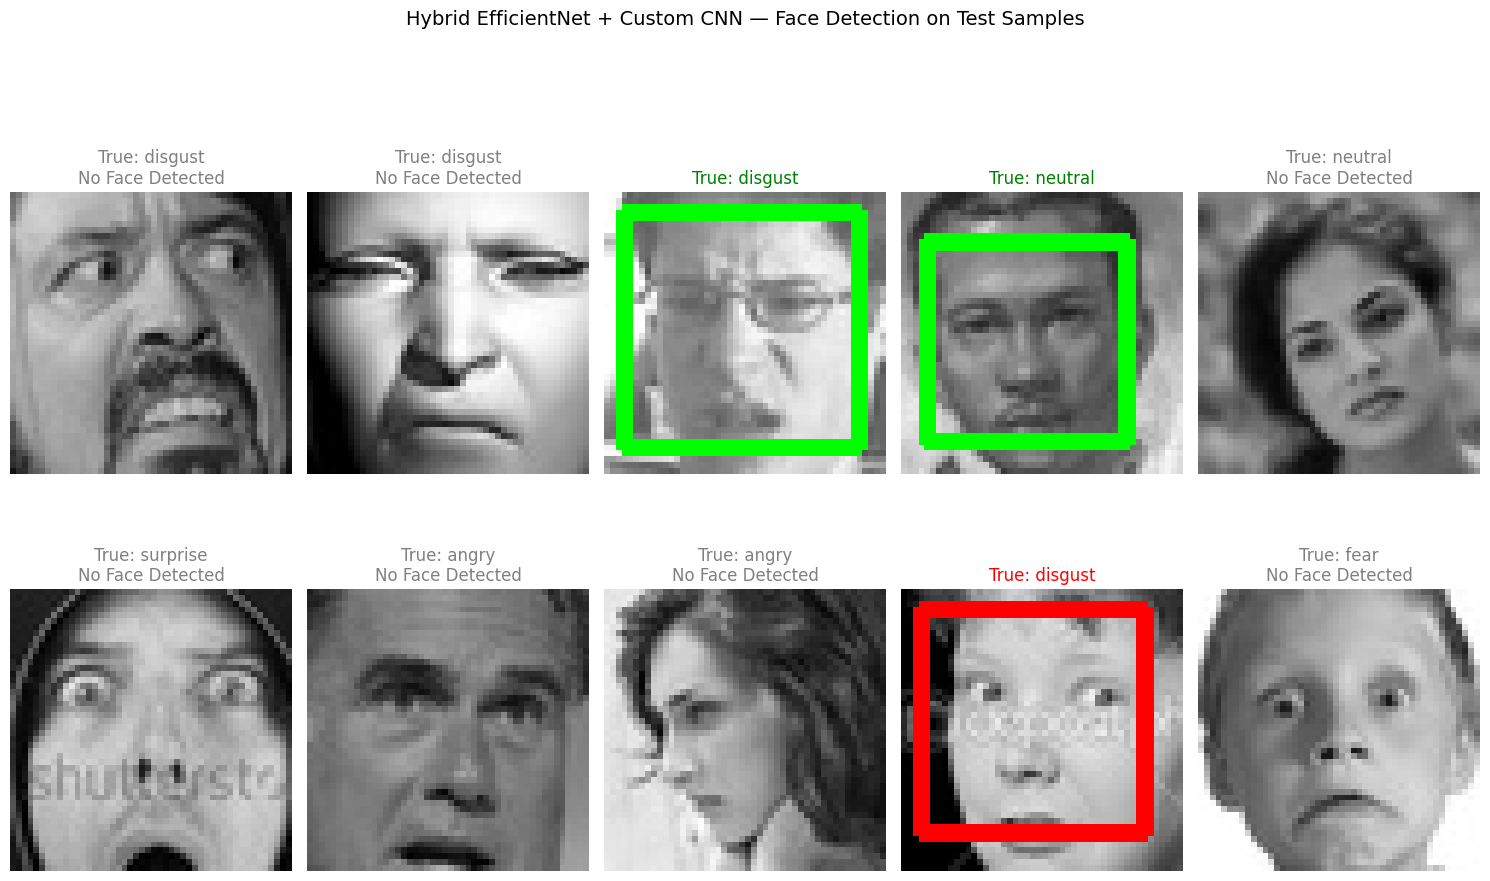

In [ ]:
# ==============================================
# 🚀 5️⃣ Run Evaluation
# ==============================================
evaluate_hybrid_model(num_samples=10)


In [ ]:
!wget -c "https://previews.123rf.com/images/bowie15/bowie151401/bowie15140100071/39843011-angry-face-man.jpg" -O angry.jpg

--2025-10-28 06:43:02--  https://previews.123rf.com/images/bowie15/bowie151401/bowie15140100071/39843011-angry-face-man.jpg
Resolving previews.123rf.com (previews.123rf.com)... 3.168.102.45, 3.168.102.91, 3.168.102.108, ...
Connecting to previews.123rf.com (previews.123rf.com)|3.168.102.45|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 187588 (183K) [image/jpeg]
Saving to: ‘angry.jpg’

angry.jpg           100%[===================>] 183.19K  --.-KB/s    in 0.02s   

2025-10-28 06:43:02 (11.2 MB/s) - ‘angry.jpg’ saved [187588/187588]



In [ ]:
!wget -c "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR1eVnaUbBcpNEEyRXr43pLDgTiXJPnoZwlQ599eELSAE_0C-jI0rASG4Bc82BfgovI-wM&usqp=CAU" -O sad.jpg

--2025-10-28 06:43:10--  https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR1eVnaUbBcpNEEyRXr43pLDgTiXJPnoZwlQ599eELSAE_0C-jI0rASG4Bc82BfgovI-wM&usqp=CAU
Resolving encrypted-tbn0.gstatic.com (encrypted-tbn0.gstatic.com)... 172.253.62.138, 172.253.62.102, 172.253.62.113, ...
Connecting to encrypted-tbn0.gstatic.com (encrypted-tbn0.gstatic.com)|172.253.62.138|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4153 (4.1K) [image/jpeg]
Saving to: ‘sad.jpg’

sad.jpg             100%[===================>]   4.06K  --.-KB/s    in 0s      

2025-10-28 06:43:10 (36.5 MB/s) - ‘sad.jpg’ saved [4153/4153]



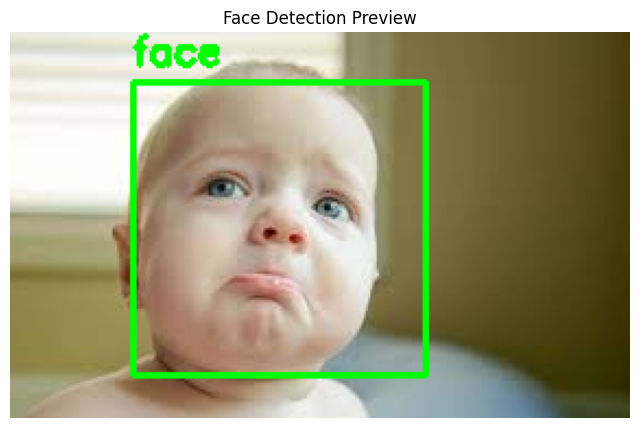

In [ ]:
# Cell 3: Test face detection on TEST_IMAGE_PATH
img_path = "/content/sad.jpg"
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Test image not found at: {img_path}")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30,30))

img_vis = img.copy()
if len(faces) == 0:
    print("No faces detected.")
else:
    for (x,y,w,h) in faces:
        cv2.rectangle(img_vis, (x,y), (x+w, y+h), (0,255,0), 2)
        # Put a small label placeholder
        cv2.putText(img_vis, "face", (x, y-8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
        break  # draw only first face for preview

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Face Detection Preview")
plt.show()


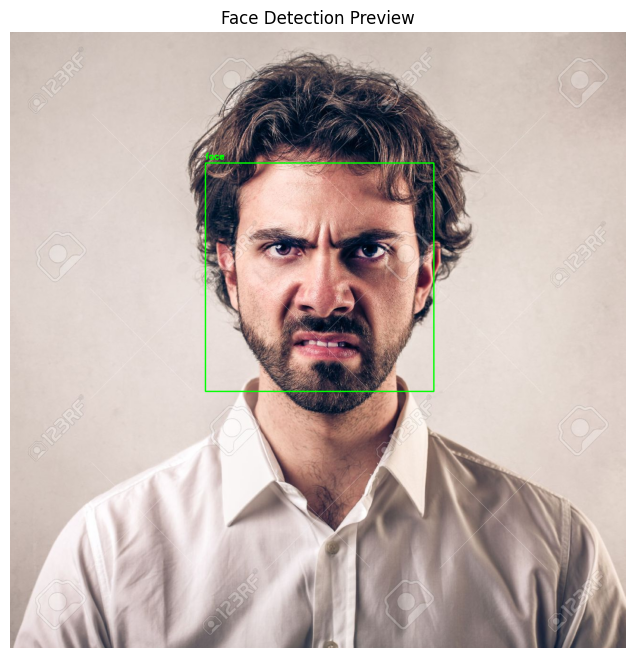

In [ ]:
# Cell 3: Test face detection on TEST_IMAGE_PATH
img_path = "/content/angry.jpg"
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Test image not found at: {img_path}")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30,30))

img_vis = img.copy()
if len(faces) == 0:
    print("No faces detected.")
else:
    for (x,y,w,h) in faces:
        cv2.rectangle(img_vis, (x,y), (x+w, y+h), (0,255,0), 2)
        # Put a small label placeholder
        cv2.putText(img_vis, "face", (x, y-8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
        break  # draw only first face for preview

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Face Detection Preview")
plt.show()


In [ ]:
# Cell 4: Load music dataset and preview
music_df = pd.read_csv("/content/data_moods.csv")
# Keep expected columns (some files have different names; adapt if necessary)
expected_cols = ['name','artist','mood','popularity']
available = [c for c in expected_cols if c in music_df.columns]
if len(available) < 3:
    print("Unexpected CSV columns. Available columns:", music_df.columns.tolist())
else:
    music_df = music_df[[c for c in expected_cols if c in music_df.columns]]
    music_df['mood'] = music_df['mood'].astype(str)
    # normalize popularity if missing or non-numeric
    if 'popularity' in music_df.columns:
        music_df['popularity'] = pd.to_numeric(music_df['popularity'], errors='coerce').fillna(0)
    display(music_df.head(10))
print("Music dataset loaded. Rows:", len(music_df))


,name,artist,mood,popularity
0,1999,Prince,Happy,68
1,23,Blonde Redhead,Sad,43
2,9 Crimes,Damien Rice,Sad,60
3,99 Luftballons,Nena,Happy,2
4,A Boy Brushed Red Living In Black And White,Underoath,Energetic,60
5,A Burden to Bear,Emmanuelle Rimbaud,Calm,27
6,A La Plage,Ron Adelaar,Calm,29
7,A Little Less Conversation - JXL Radio Edit Remix,Elvis Presley,Happy,1
8,A Place for My Head,Linkin Park,Energetic,68
9,ATTACK,Thirty Seconds To Mars,Energetic,0


Music dataset loaded. Rows: 686


In [ ]:
# Cell 6: Preprocess helper - returns (preprocessed_face, annotated_image, face_box)
def detect_and_prep_face(img_path, img_size=IMAGE_SIZE, draw_box=True):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {img_path}")
    orig = img.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30,30))
    if len(faces) == 0:
        return None, orig, None

    x,y,w,h = faces[0]  # use first face
    face_gray = gray[y:y+h, x:x+w]
    # Resize to model input
    face_resized = cv2.resize(face_gray, (img_size, img_size))
    face_resized = face_resized.astype("float32") / 255.0
    face_resized = np.expand_dims(face_resized, axis=-1)  # (H,W,1)
    if draw_box:
        cv2.rectangle(orig, (x,y), (x+w, y+h), (0,255,0), 2)
    return face_resized, orig, (x,y,w,h)


In [ ]:
# Cell 7: Predict emotion from face tensor
def predict_emotion_from_face(face_tensor, model, class_names=SELECTED_CLASSES):
    # face_tensor assumed shape (H,W,1)
    if face_tensor is None:
        return None, None
    batch = np.expand_dims(face_tensor, axis=0)  # (1,H,W,1)
    preds = model.predict(batch, verbose=0)[0]
    idx = int(np.argmax(preds))
    label = class_names[idx]
    confidence = float(preds[idx])
    return label, confidence


In [ ]:
# Cell 8: Map emotion to mood category and recommend top 10 songs by popularity
EMOTION_TO_MOOD = {
    'angry': 'Calm',
    'fear': 'Calm',
    'happy': 'Happy',
    'neutral': 'Energetic',
    'sad': 'Sad',
    'surprise': 'Energetic'
}

def recommend_top_songs_for_emotion(emotion_label, music_df, top_n=10):
    emotion_label = str(emotion_label).lower()
    mood = EMOTION_TO_MOOD.get(emotion_label, None)
    if mood is None:
        # fallback: return top popular overall
        recs = music_df.sort_values('popularity', ascending=False).head(top_n)
    else:
        df_filtered = music_df[music_df['mood'].str.lower() == mood.lower()]
        if df_filtered.shape[0] == 0:
            recs = music_df.sort_values('popularity', ascending=False).head(top_n)
        else:
            recs = df_filtered.sort_values('popularity', ascending=False).head(top_n)
    # return clean columns if available
    cols = [c for c in ['name','artist','mood','popularity'] if c in recs.columns]
    return recs[cols].reset_index(drop=True)


Predicted emotion: angry (86.90%)


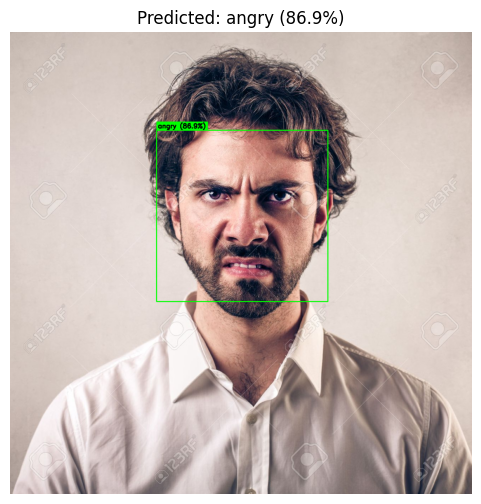


Top 10 song recommendations (by mood & popularity):


,name,artist,mood,popularity
0,Lost,Annelie,Calm,64
1,Escaping Time,Benjamin Martins,Calm,60
2,Curiosity,Beau Projet,Calm,60
3,The Choice,Gustavo Santaolalla,Calm,59
4,alpha waves,Eucalyptic,Calm,59
5,What You Love You Must Love Now,The Six Parts Seven,Calm,59
6,Vague,Amaranth Cove,Calm,59
7,Just Look at You,369,Calm,59
8,Mil Sonidos,Reina del Mar,Calm,59
9,Coda,Jakob Ahlbom,Calm,58


In [ ]:
# Cell 9: Run pipeline on a chosen image
TEST_IMAGE = "/content/angry.jpg"  # change if needed

face_tensor, annotated_img, bbox = detect_and_prep_face(TEST_IMAGE, img_size=IMAGE_SIZE, draw_box=True)
if face_tensor is None:
    print("No face detected in image:", TEST_IMAGE)
else:
    emotion_label, confidence = predict_emotion_from_face(face_tensor, hybrid_model, SELECTED_CLASSES)
    print(f"Predicted emotion: {emotion_label} ({confidence*100:.2f}%)")

    # Draw label above box if bbox present
    if bbox is not None:
        x,y,w,h = bbox
        label_text = f"{emotion_label} ({confidence*100:.1f}%)"
        # put label background rectangle
        (text_w, text_h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(annotated_img, (x, y-text_h-10), (x+text_w+8, y), (0,255,0), -1)
        cv2.putText(annotated_img, label_text, (x+4, y-6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

    # Display annotated image
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Predicted: {emotion_label} ({confidence*100:.1f}%)")
    plt.show()

    # Recommend songs
    top_songs = recommend_top_songs_for_emotion(emotion_label, music_df, top_n=10)
    print("\nTop 10 song recommendations (by mood & popularity):")
    display(top_songs)


In [ ]:
!wget -c "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR7OjpbtPqAyRGW4h4-XQjzzqupq7JQ_P1klEF78qu4jngNCl6aZz5xHgh6VL4vsFssQww&usqp=CAU" -O sad02.jpg

--2025-10-28 06:43:46--  https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR7OjpbtPqAyRGW4h4-XQjzzqupq7JQ_P1klEF78qu4jngNCl6aZz5xHgh6VL4vsFssQww&usqp=CAU
Resolving encrypted-tbn0.gstatic.com (encrypted-tbn0.gstatic.com)... 172.253.62.101, 172.253.62.102, 172.253.62.113, ...
Connecting to encrypted-tbn0.gstatic.com (encrypted-tbn0.gstatic.com)|172.253.62.101|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5834 (5.7K) [image/jpeg]
Saving to: ‘sad02.jpg’

sad02.jpg           100%[===================>]   5.70K  --.-KB/s    in 0s      

2025-10-28 06:43:46 (58.0 MB/s) - ‘sad02.jpg’ saved [5834/5834]



Predicted emotion: sad (59.02%)


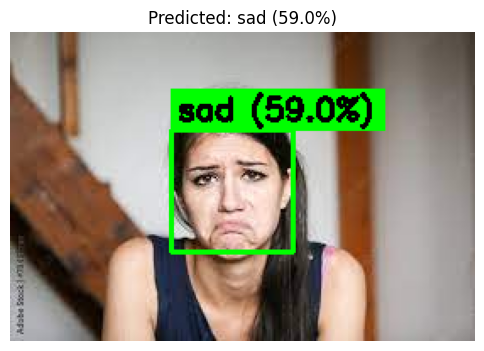


Top 10 song recommendations (by mood & popularity):


,name,artist,mood,popularity
0,lovely (with Khalid),Billie Eilish,Sad,88
1,when the party's over,Billie Eilish,Sad,87
2,you broke me first,Tate McRae,Sad,87
3,Falling,Harry Styles,Sad,87
4,All of Me,John Legend,Sad,85
5,Before You Go,Lewis Capaldi,Sad,85
6,Surrender,Natalie Taylor,Sad,84
7,Bruises,Lewis Capaldi,Sad,84
8,No Time To Die,Billie Eilish,Sad,82
9,Jealous,Labrinth,Sad,79


In [ ]:
# Cell 9: Run pipeline on a chosen image
TEST_IMAGE = "/content/sad02.jpg"  # change if needed

face_tensor, annotated_img, bbox = detect_and_prep_face(TEST_IMAGE, img_size=IMAGE_SIZE, draw_box=True)
if face_tensor is None:
    print("No face detected in image:", TEST_IMAGE)
else:
    emotion_label, confidence = predict_emotion_from_face(face_tensor, hybrid_model, SELECTED_CLASSES)
    print(f"Predicted emotion: {emotion_label} ({confidence*100:.2f}%)")

    # Draw label above box if bbox present
    if bbox is not None:
        x,y,w,h = bbox
        label_text = f"{emotion_label} ({confidence*100:.1f}%)"
        # put label background rectangle
        (text_w, text_h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(annotated_img, (x, y-text_h-10), (x+text_w+8, y), (0,255,0), -1)
        cv2.putText(annotated_img, label_text, (x+4, y-6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

    # Display annotated image
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Predicted: {emotion_label} ({confidence*100:.1f}%)")
    plt.show()

    # Recommend songs
    top_songs = recommend_top_songs_for_emotion(emotion_label, music_df, top_n=10)
    print("\nTop 10 song recommendations (by mood & popularity):")
    display(top_songs)

In [ ]:
!wget -c "https://t3.ftcdn.net/jpg/01/77/57/68/360_F_177576871_1VKEfmu5xPDib2KH3jTMRt0vGH2vBuO2.jpg" -O fear.jpg

--2025-10-28 06:43:52--  https://t3.ftcdn.net/jpg/01/77/57/68/360_F_177576871_1VKEfmu5xPDib2KH3jTMRt0vGH2vBuO2.jpg
Resolving t3.ftcdn.net (t3.ftcdn.net)... 151.101.1.91, 151.101.65.91, 151.101.129.91, ...
Connecting to t3.ftcdn.net (t3.ftcdn.net)|151.101.1.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 43374 (42K) [image/jpeg]
Saving to: ‘fear.jpg’

fear.jpg            100%[===================>]  42.36K  --.-KB/s    in 0.002s  

2025-10-28 06:43:52 (18.2 MB/s) - ‘fear.jpg’ saved [43374/43374]



Predicted emotion: fear (74.45%)


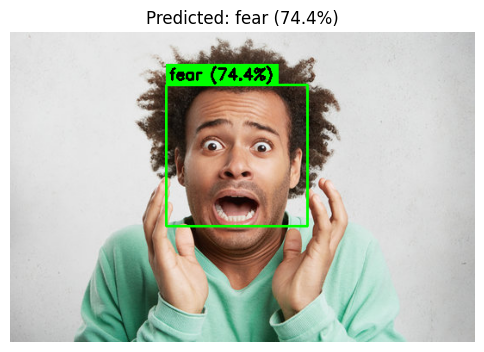


Top 10 song recommendations (by mood & popularity):


,name,artist,mood,popularity
0,Lost,Annelie,Calm,64
1,Escaping Time,Benjamin Martins,Calm,60
2,Curiosity,Beau Projet,Calm,60
3,The Choice,Gustavo Santaolalla,Calm,59
4,alpha waves,Eucalyptic,Calm,59
5,What You Love You Must Love Now,The Six Parts Seven,Calm,59
6,Vague,Amaranth Cove,Calm,59
7,Just Look at You,369,Calm,59
8,Mil Sonidos,Reina del Mar,Calm,59
9,Coda,Jakob Ahlbom,Calm,58


In [ ]:
# Cell 9: Run pipeline on a chosen image
TEST_IMAGE = "/content/fear.jpg"  # change if needed

face_tensor, annotated_img, bbox = detect_and_prep_face(TEST_IMAGE, img_size=IMAGE_SIZE, draw_box=True)
if face_tensor is None:
    print("No face detected in image:", TEST_IMAGE)
else:
    emotion_label, confidence = predict_emotion_from_face(face_tensor, hybrid_model, SELECTED_CLASSES)
    print(f"Predicted emotion: {emotion_label} ({confidence*100:.2f}%)")

    # Draw label above box if bbox present
    if bbox is not None:
        x,y,w,h = bbox
        label_text = f"{emotion_label} ({confidence*100:.1f}%)"
        # put label background rectangle
        (text_w, text_h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(annotated_img, (x, y-text_h-10), (x+text_w+8, y), (0,255,0), -1)
        cv2.putText(annotated_img, label_text, (x+4, y-6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

    # Display annotated image
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Predicted: {emotion_label} ({confidence*100:.1f}%)")
    plt.show()

    # Recommend songs
    top_songs = recommend_top_songs_for_emotion(emotion_label, music_df, top_n=10)
    print("\nTop 10 song recommendations (by mood & popularity):")
    display(top_songs)

In [ ]:
!wget -c "https://thumbs.dreamstime.com/b/happy-joyful-little-girl-smiling-hands-near-face-isolated-white-background-60797111.jpg" -O happy.jpg

--2025-10-28 06:44:16--  https://thumbs.dreamstime.com/b/happy-joyful-little-girl-smiling-hands-near-face-isolated-white-background-60797111.jpg
Resolving thumbs.dreamstime.com (thumbs.dreamstime.com)... 151.101.1.91, 151.101.65.91, 151.101.129.91, ...
Connecting to thumbs.dreamstime.com (thumbs.dreamstime.com)|151.101.1.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37614 (37K) [image/jpeg]
Saving to: ‘happy.jpg’

happy.jpg           100%[===================>]  36.73K  --.-KB/s    in 0s      

2025-10-28 06:44:16 (110 MB/s) - ‘happy.jpg’ saved [37614/37614]



Predicted emotion: happy (98.22%)


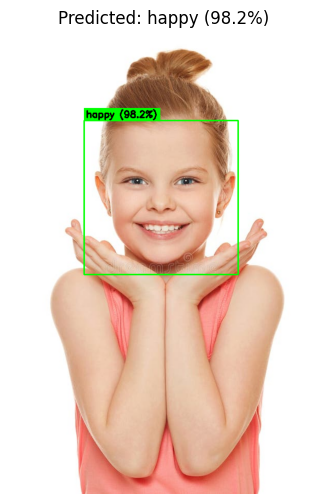


Top 10 song recommendations (by mood & popularity):


,name,artist,mood,popularity
0,Africa,TOTO,Happy,84
1,Take on Me,a-ha,Happy,84
2,Pumped Up Kicks,Foster The People,Happy,84
3,Highway to Hell,AC/DC,Happy,83
4,Here Comes The Sun - Remastered 2009,The Beatles,Happy,83
5,Mr. Blue Sky,Electric Light Orchestra,Happy,82
6,"Rocket Man (I Think It's Going To Be A Long, L...",Elton John,Happy,82
7,Paradise,Coldplay,Happy,80
8,Get Lucky (feat. Pharrell Williams & Nile Rodg...,Daft Punk,Happy,78
9,Little Talks,Of Monsters and Men,Happy,78


In [ ]:
# Cell 9: Run pipeline on a chosen image
TEST_IMAGE = "/content/happy.jpg"  # change if needed

face_tensor, annotated_img, bbox = detect_and_prep_face(TEST_IMAGE, img_size=IMAGE_SIZE, draw_box=True)
if face_tensor is None:
    print("No face detected in image:", TEST_IMAGE)
else:
    emotion_label, confidence = predict_emotion_from_face(face_tensor, hybrid_model, SELECTED_CLASSES)
    print(f"Predicted emotion: {emotion_label} ({confidence*100:.2f}%)")

    # Draw label above box if bbox present
    if bbox is not None:
        x,y,w,h = bbox
        label_text = f"{emotion_label} ({confidence*100:.1f}%)"
        # put label background rectangle
        (text_w, text_h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(annotated_img, (x, y-text_h-10), (x+text_w+8, y), (0,255,0), -1)
        cv2.putText(annotated_img, label_text, (x+4, y-6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

    # Display annotated image
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Predicted: {emotion_label} ({confidence*100:.1f}%)")
    plt.show()

    # Recommend songs
    top_songs = recommend_top_songs_for_emotion(emotion_label, music_df, top_n=10)
    print("\nTop 10 song recommendations (by mood & popularity):")
    display(top_songs)

In [ ]:
!wget -c "https://t3.ftcdn.net/jpg/03/42/85/16/360_F_342851651_BV9SYWnoTPSu3kq6e82zG7H8eEt20wd1.jpg" -O nuetral.jpg

--2025-10-28 06:44:24--  https://t3.ftcdn.net/jpg/03/42/85/16/360_F_342851651_BV9SYWnoTPSu3kq6e82zG7H8eEt20wd1.jpg
Resolving t3.ftcdn.net (t3.ftcdn.net)... 151.101.1.91, 151.101.65.91, 151.101.129.91, ...
Connecting to t3.ftcdn.net (t3.ftcdn.net)|151.101.1.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23886 (23K) [image/jpeg]
Saving to: ‘nuetral.jpg’

nuetral.jpg         100%[===================>]  23.33K  --.-KB/s    in 0s      

2025-10-28 06:44:24 (90.6 MB/s) - ‘nuetral.jpg’ saved [23886/23886]



Predicted emotion: neutral (65.68%)


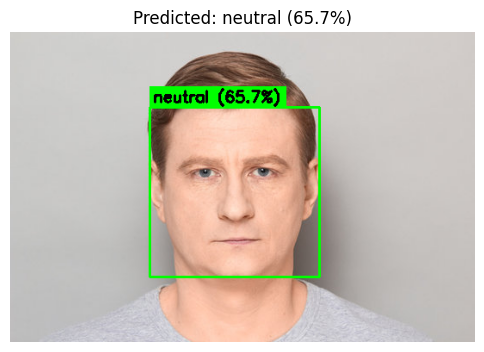


Top 10 song recommendations (by mood & popularity):


,name,artist,mood,popularity
0,Chop Suey!,System Of A Down,Energetic,79
1,Killing In The Name,Rage Against The Machine,Energetic,78
2,Dani California,Red Hot Chili Peppers,Energetic,77
3,Duality,Slipknot,Energetic,76
4,Uprising,Muse,Energetic,75
5,I'm Not Okay (I Promise),My Chemical Romance,Energetic,73
6,Papercut,Linkin Park,Energetic,73
7,My Own Worst Enemy,Lit,Energetic,72
8,Savior,Rise Against,Energetic,70
9,Falling Away from Me,Korn,Energetic,70


In [ ]:
# Cell 9: Run pipeline on a chosen image
TEST_IMAGE = "/content/nuetral.jpg"  # change if needed

face_tensor, annotated_img, bbox = detect_and_prep_face(TEST_IMAGE, img_size=IMAGE_SIZE, draw_box=True)
if face_tensor is None:
    print("No face detected in image:", TEST_IMAGE)
else:
    emotion_label, confidence = predict_emotion_from_face(face_tensor, hybrid_model, SELECTED_CLASSES)
    print(f"Predicted emotion: {emotion_label} ({confidence*100:.2f}%)")

    # Draw label above box if bbox present
    if bbox is not None:
        x,y,w,h = bbox
        label_text = f"{emotion_label} ({confidence*100:.1f}%)"
        # put label background rectangle
        (text_w, text_h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(annotated_img, (x, y-text_h-10), (x+text_w+8, y), (0,255,0), -1)
        cv2.putText(annotated_img, label_text, (x+4, y-6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

    # Display annotated image
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Predicted: {emotion_label} ({confidence*100:.1f}%)")
    plt.show()

    # Recommend songs
    top_songs = recommend_top_songs_for_emotion(emotion_label, music_df, top_n=10)
    print("\nTop 10 song recommendations (by mood & popularity):")
    display(top_songs)

In [1]:
!pip install streamlit pyngrok tensorflow opencv-python pandas matplotlib



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 68.7 MB/s eta 0:00:00


In [5]:
from pyngrok import ngrok
# Paste your ngrok auth token below (optional but recommended)
ngrok.set_auth_token("2xanpdMDvyt7nCyuQPGJ0qt9rxu_3q2zG56gzmG49jhowjEZt")


In [ ]:
# %%writefile app.py
# import streamlit as st
# import tensorflow as tf
# import numpy as np
# import pandas as pd
# import cv2
# from tensorflow.keras.preprocessing import image
# from PIL import Image
# import tempfile
# import os

# # ==============================================
# # ⚙️ CONFIGURATION
# # ==============================================
# st.set_page_config(page_title="Emotion Music Recommender", page_icon="🎧", layout="centered")

# IMAGE_SIZE = 96
# CLASS_LABELS = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
# DATA_PATH = "/content/data_moods.csv"   # your dataset
# MODEL_PATH = "/content/fer_hybrid_efficientnet_custom_model.h5"  # trained model

# # ==============================================
# # 🧠 Load Model & Dataset
# # ==============================================
# @st.cache_resource
# def load_model():
#     model = tf.keras.models.load_model(MODEL_PATH)
#     return model

# @st.cache_data
# def load_dataset():
#     df = pd.read_csv(DATA_PATH)
#     return df

# hybrid_model = load_model()
# music_df = load_dataset()

# # ==============================================
# # 🎯 Emotion → Mood Mapping
# # ==============================================
# emotion_to_mood = {
#     'angry': 'Calm',
#     'fear': 'Calm',
#     'happy': 'Happy',
#     'neutral': 'Energetic',
#     'sad': 'Sad',
#     'surprise': 'Energetic'
# }

# # ==============================================
# # 🧰 Helper Functions
# # ==============================================
# def detect_faces_and_draw(img_array):
#     """Detect faces and return cropped faces + image with rectangles."""
#     face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
#     gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
#     faces = face_cascade.detectMultiScale(gray, 1.1, 5)
#     faces_list = []
#     for (x, y, w, h) in faces:
#         cv2.rectangle(img_array, (x, y), (x+w, y+h), (0, 255, 0), 2)
#         faces_list.append(gray[y:y+h, x:x+w])
#     return faces_list, img_array

# def preprocess_face(face_img):
#     face_resized = cv2.resize(face_img, (IMAGE_SIZE, IMAGE_SIZE))
#     face_resized = face_resized / 255.0
#     face_resized = np.expand_dims(face_resized, axis=-1)
#     face_resized = np.expand_dims(face_resized, axis=0)
#     return face_resized

# def predict_emotion(face_img):
#     preprocessed = preprocess_face(face_img)
#     preds = hybrid_model.predict(preprocessed, verbose=0)
#     pred_label = CLASS_LABELS[np.argmax(preds)]
#     confidence = np.max(preds) * 100
#     return pred_label, confidence

# def recommend_music(emotion_label, top_n=10):
#     """Map emotion to mood and recommend top songs by popularity."""
#     mapped_mood = emotion_to_mood.get(emotion_label.lower(), None)
#     if not mapped_mood:
#         st.warning(f"No mood mapping found for emotion '{emotion_label}'. Showing random songs instead.")
#         filtered = music_df.sample(n=top_n)
#     else:
#         filtered = music_df[music_df['mood'].str.lower() == mapped_mood.lower()]
#         if filtered.empty:
#             st.warning(f"No songs found for mood '{mapped_mood}'. Showing random songs instead.")
#             filtered = music_df.sample(n=top_n)
#         else:
#             if 'popularity' in filtered.columns:
#                 filtered = filtered.sort_values(by='popularity', ascending=False)
#     return filtered.head(top_n)[['name', 'artist', 'mood', 'popularity']]

# # ==============================================
# # 🎨 Streamlit UI
# # ==============================================
# st.title("🎧 Emotion-Based Music Recommender")
# st.markdown("Upload your face photo and get **music recommendations** that match your current mood 🎵")

# uploaded_file = st.file_uploader("Upload an Image", type=["jpg", "jpeg", "png"])

# if uploaded_file:
#     # ✅ FIXED: Correct image decoding for Streamlit
#     image_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)
#     img_array = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)

#     if img_array is None:
#         st.error("⚠️ Unable to read the uploaded image. Please try another photo.")
#     else:
#         faces, img_with_box = detect_faces_and_draw(img_array)

#         # ✅ Show image with bounding boxes
#         st.image(cv2.cvtColor(img_with_box, cv2.COLOR_BGR2RGB), caption="Detected Face(s)", use_container_width=True)

#         if not faces:
#             st.error("No face detected! Please upload a clear photo with a visible face.")
#         else:
#             face = faces[0]
#             pred_label, confidence = predict_emotion(face)
#             mapped_mood = emotion_to_mood.get(pred_label.lower(), "Unknown")

#             st.success(f"🧠 Detected Emotion: **{pred_label.upper()}** ({confidence:.1f}%)")
#             st.subheader(f"🎵 Recommended Songs for Mood: {mapped_mood}")

#             top_songs = recommend_music(pred_label, top_n=10)
#             if top_songs.empty:
#                 st.error("No songs available for this mood mapping.")
#             else:
#                 for idx, row in top_songs.iterrows():
#                     st.markdown(
#                         f"**{row['name']}** — *{row['artist']}*  \n"
#                         f"🎶 Mood: {row['mood']}  \n"
#                         f"⭐ Popularity: {int(row['popularity'])}"
#                     )

# st.markdown("---")
# st.caption("Built with ❤️ using Streamlit, TensorFlow & OpenCV")


Writing app.py


In [2]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
import pandas as pd
import cv2
import tempfile
import time
from PIL import Image

# ==============================================
# ⚙️ CONFIGURATION
# ==============================================
st.set_page_config(page_title="Emotion Music Recommender", page_icon="🎧", layout="centered")

IMAGE_SIZE = 96
CLASS_LABELS = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
DATA_PATH = "/content/data_moods.csv"   # your dataset
MODEL_PATH = "/content/fer_hybrid_efficientnet_custom_model.h5"  # trained model

# ==============================================
# 🧠 Load Model & Dataset
# ==============================================
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model(MODEL_PATH)
    return model

@st.cache_data
def load_dataset():
    df = pd.read_csv(DATA_PATH)
    return df

hybrid_model = load_model()
music_df = load_dataset()

# ==============================================
# 🎯 Emotion → Mood Mapping
# ==============================================
emotion_to_mood = {
    'angry': 'Calm',
    'fear': 'Calm',
    'happy': 'Happy',
    'neutral': 'Energetic',
    'sad': 'Sad',
    'surprise': 'Energetic'
}

# ==============================================
# 🧰 Helper Functions
# ==============================================
def detect_faces_and_draw(img_array, emotion_texts=None):
    """Detect faces, draw rectangles + emotion labels, return cropped faces."""
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray = cv2.cvtColor(img_array, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    faces_list = []

    for i, (x, y, w, h) in enumerate(faces):
        cv2.rectangle(img_array, (x, y), (x+w, y+h), (0, 255, 0), 2)
        if emotion_texts and i < len(emotion_texts):
            cv2.putText(img_array, emotion_texts[i], (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        faces_list.append(gray[y:y+h, x:x+w])
    return faces_list, img_array

def preprocess_face(face_img):
    face_resized = cv2.resize(face_img, (IMAGE_SIZE, IMAGE_SIZE))
    face_resized = face_resized / 255.0
    face_resized = np.expand_dims(face_resized, axis=-1)
    face_resized = np.expand_dims(face_resized, axis=0)
    return face_resized

def predict_emotion(face_img):
    preprocessed = preprocess_face(face_img)
    preds = hybrid_model.predict(preprocessed, verbose=0)
    pred_label = CLASS_LABELS[np.argmax(preds)]
    confidence = np.max(preds) * 100
    return pred_label, confidence

def recommend_music(emotion_label, top_n=10):
    mapped_mood = emotion_to_mood.get(emotion_label.lower(), None)
    if not mapped_mood:
        st.warning(f"No mood mapping found for emotion '{emotion_label}'. Showing random songs instead.")
        filtered = music_df.sample(n=top_n)
    else:
        filtered = music_df[music_df['mood'].str.lower() == mapped_mood.lower()]
        if filtered.empty:
            st.warning(f"No songs found for mood '{mapped_mood}'. Showing random songs instead.")
            filtered = music_df.sample(n=top_n)
        else:
            if 'popularity' in filtered.columns:
                filtered = filtered.sort_values(by='popularity', ascending=False)
    return filtered.head(top_n)[['name', 'artist', 'mood', 'popularity']]

# ==============================================
# 🎨 Streamlit UI
# ==============================================
st.title("🎧 Emotion-Based Music Recommender")
st.markdown("Detect your mood and get personalized music recommendations 🎵")

mode = st.radio("Choose Mode:", ["📸 Upload Image", "🎥 Use Webcam"])

# ==============================================
# 📸 IMAGE UPLOAD MODE
# ==============================================
if mode == "📸 Upload Image":
    uploaded_file = st.file_uploader("Upload an Image", type=["jpg", "jpeg", "png"])

    if uploaded_file:
        with tempfile.NamedTemporaryFile(delete=False) as tmp_file:
            tmp_file.write(uploaded_file.read())
            temp_path = tmp_file.name

        img_array = cv2.imread(temp_path)
        faces, _ = detect_faces_and_draw(img_array)

        emotion_texts = []
        for face in faces:
            label, confidence = predict_emotion(face)
            emotion_texts.append(f"{label} ({confidence:.1f}%)")

        # Re-draw image with emotion labels
        faces, img_with_box = detect_faces_and_draw(img_array, emotion_texts)
        st.image(cv2.cvtColor(img_with_box, cv2.COLOR_BGR2RGB), caption="Detected Face(s)", use_container_width=True)

        if not faces:
            st.error("No face detected! Please upload a clear photo with a visible face.")
        else:
            label, confidence = predict_emotion(faces[0])
            mapped_mood = emotion_to_mood.get(label.lower(), "Unknown")

            st.success(f"🧠 Detected Emotion: **{label.upper()}** ({confidence:.1f}%)")
            st.subheader(f"🎵 Recommended Songs for Mood: {mapped_mood}")

            top_songs = recommend_music(label, top_n=10)
            for idx, row in top_songs.iterrows():
                st.markdown(
                    f"**{row['name']}** — *{row['artist']}*  \n"
                    f"🎶 Mood: {row['mood']}  \n"
                    f"⭐ Popularity: {int(row['popularity'])}"
                )

# ==============================================
# 🎥 WEBCAM MODE
# ==============================================
elif mode == "🎥 Use Webcam":
    st.info("Click 'Start Webcam' to detect faces and emotions in real-time.")
    run_webcam = st.button("▶️ Start Webcam")

    if run_webcam:
        cap = cv2.VideoCapture(0)
        stframe = st.empty()
        current_emotion = None
        last_update = time.time()

        while True:
            ret, frame = cap.read()
            if not ret:
                st.error("Failed to access webcam.")
                break

            faces, _ = detect_faces_and_draw(frame)
            emotion_texts = []
            emotions_detected = []

            for face in faces:
                label, confidence = predict_emotion(face)
                emotion_texts.append(f"{label}")
                emotions_detected.append(label)

            faces, img_with_box = detect_faces_and_draw(frame, emotion_texts)
            stframe.image(cv2.cvtColor(img_with_box, cv2.COLOR_BGR2RGB), channels="RGB", use_container_width=True)

            # Update music recommendations every 5 seconds
            if emotions_detected and (time.time() - last_update) > 5:
                current_emotion = emotions_detected[0]
                st.write(f"🧠 Current Emotion: **{current_emotion.upper()}**")
                mood = emotion_to_mood.get(current_emotion.lower(), "Unknown")
                st.subheader(f"🎵 Songs for Mood: {mood}")

                top_songs = recommend_music(current_emotion, top_n=5)
                for idx, row in top_songs.iterrows():
                    st.markdown(
                        f"**{row['name']}** — *{row['artist']}*  \n"
                        f"🎶 Mood: {row['mood']}  \n"
                        f"⭐ Popularity: {int(row['popularity'])}"
                    )
                last_update = time.time()

            if st.button("⏹ Stop Webcam"):
                cap.release()
                st.success("Webcam stopped.")
                break

st.markdown("---")
st.caption("Built with ❤️ using Streamlit, TensorFlow & OpenCV")


Writing app.py


In [6]:
from pyngrok import ngrok
import subprocess

# Run Streamlit in background
port = 8501
ngrok_tunnel = ngrok.connect(port)
public_url = ngrok_tunnel.public_url
print("🌍 Public URL:", public_url)

# Start Streamlit
subprocess.run(["streamlit", "run", "app.py", "--server.port", str(port)])


🌍 Public URL: https://4bc2fd62a624.ngrok-free.app


KeyboardInterrupt: 

In [3]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.75.142.212:8501

y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙your url is: https://salty-chairs-tease.loca.lt
piyush123
  Stopping...
^C
